### SHAP - CPU -version

In [2]:
import pandas as pd
df = pd.read_csv("mushroom_encoded.csv")

df.head()

,class,cap-diameter,does-bruise-or-bleed,stem-height,stem-width,has-ring,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_o,...,habitat_h,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,season_a,season_s,season_u,season_w
0,1,15.26,0,16.95,17.09,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,1,16.60,0,17.99,18.19,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,1,14.07,0,17.80,17.74,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1,14.17,0,15.77,15.98,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
4,1,14.64,0,16.53,17.20,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [3]:
df.columns

Index(['class', 'cap-diameter', 'does-bruise-or-bleed', 'stem-height',
       'stem-width', 'has-ring', 'cap-shape_b', 'cap-shape_c', 'cap-shape_f',
       'cap-shape_o', 'cap-shape_p', 'cap-shape_s', 'cap-shape_x',
       'cap-surface_d', 'cap-surface_e', 'cap-surface_g', 'cap-surface_h',
       'cap-surface_i', 'cap-surface_k', 'cap-surface_l',
       'cap-surface_missing', 'cap-surface_s', 'cap-surface_t',
       'cap-surface_w', 'cap-surface_y', 'cap-color_b', 'cap-color_e',
       'cap-color_g', 'cap-color_k', 'cap-color_l', 'cap-color_n',
       'cap-color_o', 'cap-color_p', 'cap-color_r', 'cap-color_u',
       'cap-color_w', 'cap-color_y', 'gill-attachment_a', 'gill-attachment_d',
       'gill-attachment_e', 'gill-attachment_f', 'gill-attachment_missing',
       'gill-attachment_p', 'gill-attachment_s', 'gill-attachment_x',
       'gill-spacing_c', 'gill-spacing_d', 'gill-spacing_f',
       'gill-spacing_missing', 'gill-color_b', 'gill-color_e', 'gill-color_f',
       'gill-colo

In [4]:
# remove special characters
df.columns = (
    df.columns
    .str.replace('<', '', regex=False)
    .str.replace('>', '', regex=False)
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
    .str.replace(' ', '_', regex=False)
)

In [5]:
df.columns

Index(['class', 'cap-diameter', 'does-bruise-or-bleed', 'stem-height',
       'stem-width', 'has-ring', 'cap-shape_b', 'cap-shape_c', 'cap-shape_f',
       'cap-shape_o', 'cap-shape_p', 'cap-shape_s', 'cap-shape_x',
       'cap-surface_d', 'cap-surface_e', 'cap-surface_g', 'cap-surface_h',
       'cap-surface_i', 'cap-surface_k', 'cap-surface_l',
       'cap-surface_missing', 'cap-surface_s', 'cap-surface_t',
       'cap-surface_w', 'cap-surface_y', 'cap-color_b', 'cap-color_e',
       'cap-color_g', 'cap-color_k', 'cap-color_l', 'cap-color_n',
       'cap-color_o', 'cap-color_p', 'cap-color_r', 'cap-color_u',
       'cap-color_w', 'cap-color_y', 'gill-attachment_a', 'gill-attachment_d',
       'gill-attachment_e', 'gill-attachment_f', 'gill-attachment_missing',
       'gill-attachment_p', 'gill-attachment_s', 'gill-attachment_x',
       'gill-spacing_c', 'gill-spacing_d', 'gill-spacing_f',
       'gill-spacing_missing', 'gill-color_b', 'gill-color_e', 'gill-color_f',
       'gill-colo

Feature Importances using SHAP:
                 Feature  Importance
0           cap-diameter    0.015323
1   does-bruise-or-bleed    0.018610
2            stem-height    0.035506
3             stem-width    0.126366
4               has-ring    0.015169
..                   ...         ...
89             habitat_w    0.000018
90              season_a    0.000133
91              season_s    0.001137
92              season_u    0.000083
93              season_w    0.000220

[94 rows x 2 columns]


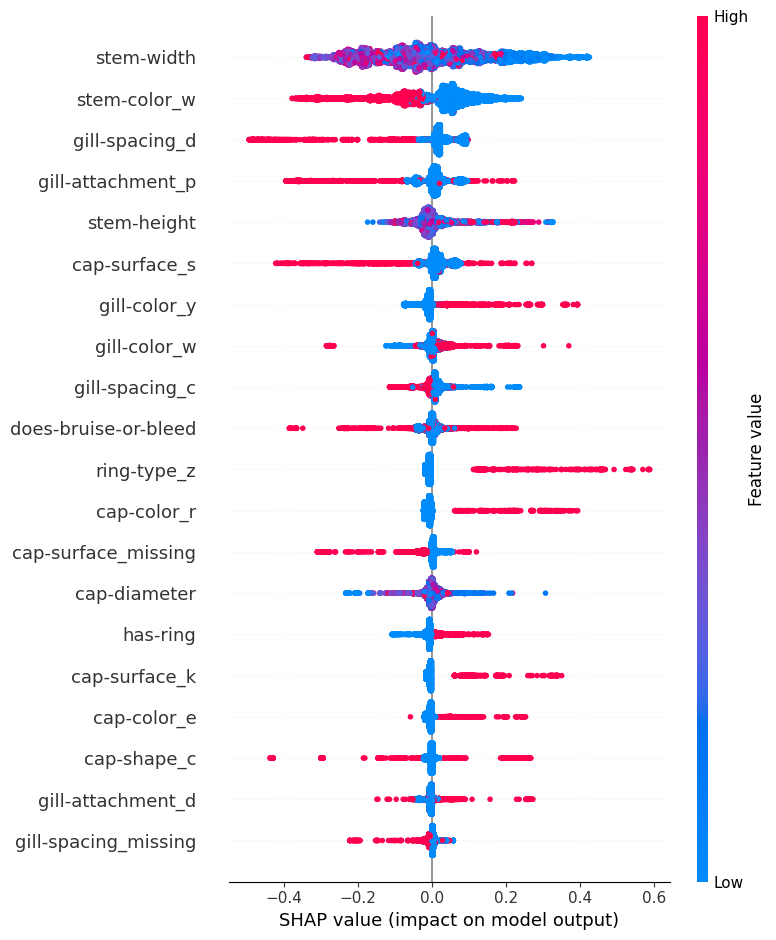

In [8]:
import shap
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Define features and target
X = df[['cap-diameter', 'does-bruise-or-bleed', 'stem-height',
       'stem-width', 'has-ring', 'cap-shape_b', 'cap-shape_c', 'cap-shape_f',
       'cap-shape_o', 'cap-shape_p', 'cap-shape_s', 'cap-shape_x',
       'cap-surface_d', 'cap-surface_e', 'cap-surface_g', 'cap-surface_h',
       'cap-surface_i', 'cap-surface_k', 'cap-surface_l',
       'cap-surface_missing', 'cap-surface_s', 'cap-surface_t',
       'cap-surface_w', 'cap-surface_y', 'cap-color_b', 'cap-color_e',
       'cap-color_g', 'cap-color_k', 'cap-color_l', 'cap-color_n',
       'cap-color_o', 'cap-color_p', 'cap-color_r', 'cap-color_u',
       'cap-color_w', 'cap-color_y', 'gill-attachment_a', 'gill-attachment_d',
       'gill-attachment_e', 'gill-attachment_f', 'gill-attachment_missing',
       'gill-attachment_p', 'gill-attachment_s', 'gill-attachment_x',
       'gill-spacing_c', 'gill-spacing_d', 'gill-spacing_f',
       'gill-spacing_missing', 'gill-color_b', 'gill-color_e', 'gill-color_f',
       'gill-color_g', 'gill-color_k', 'gill-color_n', 'gill-color_o',
       'gill-color_p', 'gill-color_r', 'gill-color_u', 'gill-color_w',
       'gill-color_y', 'stem-color_b', 'stem-color_e', 'stem-color_f',
       'stem-color_g', 'stem-color_k', 'stem-color_l', 'stem-color_n',
       'stem-color_o', 'stem-color_p', 'stem-color_r', 'stem-color_u',
       'stem-color_w', 'stem-color_y', 'ring-type_e', 'ring-type_f',
       'ring-type_g', 'ring-type_l', 'ring-type_m', 'ring-type_missing',
       'ring-type_p', 'ring-type_r', 'ring-type_z', 'habitat_d', 'habitat_g',
       'habitat_h', 'habitat_l', 'habitat_m', 'habitat_p', 'habitat_u',
       'habitat_w', 'season_a', 'season_s', 'season_u', 'season_w']]

y = df['class']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Train model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Initialize SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Plot SHAP summary
shap.summary_plot(shap_values, X_test, show=False)

# Feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.mean(np.abs(shap_values), axis=0)
})

print("Feature Importances using SHAP:")
print(importance)